In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [3]:
X,y = make_blobs(n_samples=250,centers=4,random_state=42)

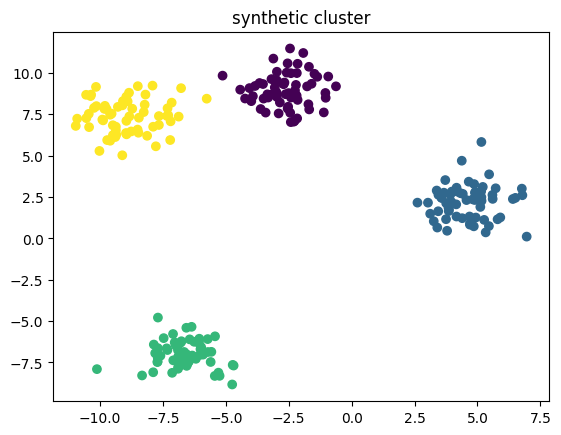

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.title("synthetic cluster")
plt.show()

In [5]:
#Elbow method is used to find the optimal number of clusters
cent = []
for k in range(1,11):
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X)
    cent.append(km.inertia_)

In [6]:
cent

[16751.92493210407,
 7791.29846535955,
 1794.2597172650499,
 473.55459034342437,
 429.4768642116301,
 398.994455332048,
 359.6575035848576,
 304.6438899721443,
 278.6129429115639,
 268.8088211691612]

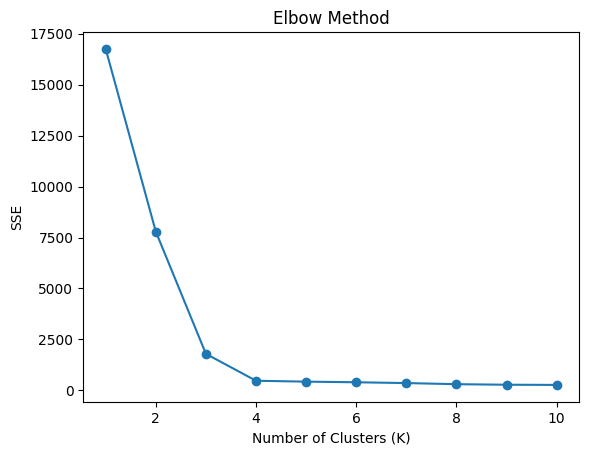

In [7]:
plt.plot(range(1,11), cent, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

In [8]:
# do K means clustering  without any library

In [9]:
import pandas as pd
import numpy as np

In [10]:
df = pd.read_csv("income.csv")

In [11]:
df.columns.tolist()

['Name', 'Age', 'Income($)']

In [12]:
dfc = df[['Age','Income($)']].copy()
dfc.head()

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000


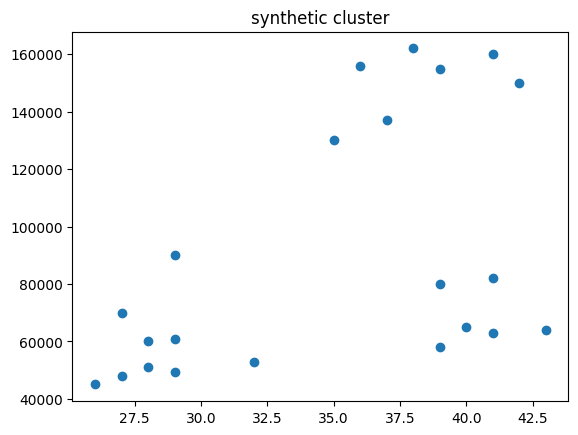

In [13]:
plt.scatter(dfc['Age'],dfc['Income($)'])
plt.title("synthetic cluster")
plt.show()

In [14]:
km = KMeans(n_clusters=3)
km.fit(dfc)
y_predict = km.fit_predict(dfc)
km.cluster_centers_

array([[3.82857143e+01, 1.50000000e+05],
       [3.24166667e+01, 5.72916667e+04],
       [3.63333333e+01, 8.40000000e+04]])

In [15]:
dfc['cluster'] = y_predict
dfc.head()

,Age,Income($),cluster
0,27,70000,1
1,29,90000,2
2,29,61000,1
3,28,60000,1
4,42,150000,0


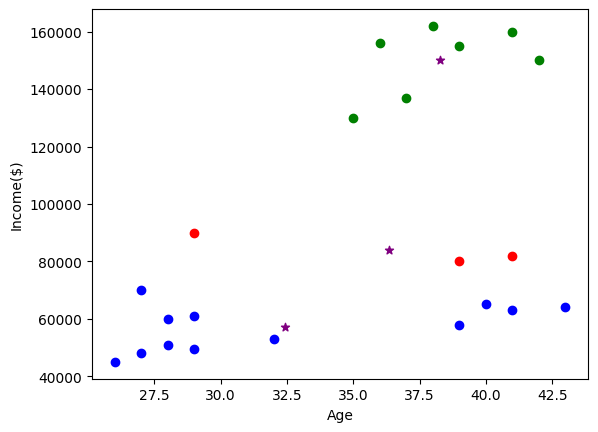

In [16]:
df1 = dfc[dfc.cluster == 0]
df2 = dfc[dfc.cluster == 1]
df3 = dfc[dfc.cluster == 2]
plt.scatter(df1.Age, df1['Income($)'],color='green')
plt.scatter(df2.Age, df2['Income($)'],color='blue')
plt.scatter(df3.Age, df3['Income($)'],color='red')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.show()

In [17]:
from sklearn.preprocessing import MinMaxScaler
dfx = df[['Age','Income($)']].copy()
dfx.head()
scaler = MinMaxScaler()
dfx['Income($)'] = scaler.fit_transform(dfx[['Income($)']])
dfx['Age'] = scaler.fit_transform(dfx[['Age']])

In [18]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [19]:
km = KMeans(n_clusters=3)
y_predict = km.fit_predict(dfx)

In [20]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ],
       [0.72268908, 0.8974359 ]])

In [21]:
dfx['cluster'] = y_predict
dfx.head()

,Age,Income($),cluster
0,0.058824,0.213675,0
1,0.176471,0.384615,0
2,0.176471,0.136752,0
3,0.117647,0.128205,0
4,0.941176,0.897436,2


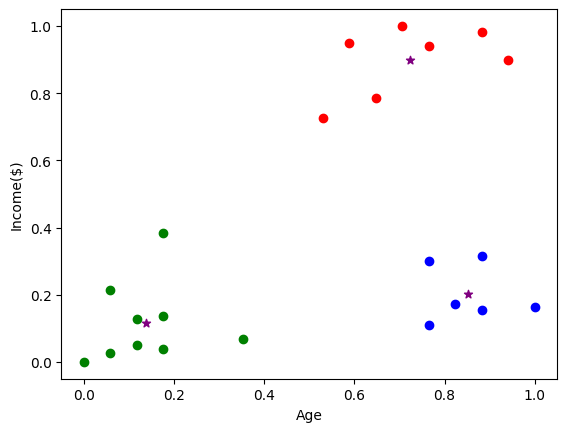

In [22]:
df1 = dfx[dfx.cluster == 0]
df2 = dfx[dfx.cluster == 1]
df3 = dfx[dfx.cluster == 2]
plt.scatter(df1.Age, df1['Income($)'],color='green')
plt.scatter(df2.Age, df2['Income($)'],color='blue')
plt.scatter(df3.Age, df3['Income($)'],color='red')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.show()